In [1]:
import torch
import numpy as np

from zsl_utils.olmo import get_olmo_model_steps
from zsl_utils.mpl import *
from zsl_config import ZSL_DIR_ANALYSIS

In [6]:
EVAL_DIR_DDP = ZSL_DIR_ANALYSIS / 'LL_xsections_debug_ddp/olmo'
EVAL_DIR_FIX = ZSL_DIR_ANALYSIS / 'LL_xsections_debug_ddp_fix/olmo'


RUNS = [
        '1028-rmsnorm-14m',
        '1028-rmsnorm-37m',
        '1028-rmsnorm-78m',
        '1028-rmsnorm-144m',
        '1028-rmsnorm-285m',
        '1028-rmsnorm-472m',
    ]
runs_to_plot = RUNS[:3]

def get_run_train_batch_steps(run: str, fix: bool = False):
    run_dir = EVAL_DIR / run 
    return sorted([int(d.stem.replace('train_batch=','')) for d in run_dir.glob("train_batch=[1-9]*")])

def get_metrics_train(run: str, step: int, train_batch_step: int, fix: bool = False):
    EVAL_DIR = EVAL_DIR_FIX if fix else EVAL_DIR_DDP
    f = EVAL_DIR / run / f"train_batch={train_batch_step}/train/step{step}.pt"
    return torch.load(f,  weights_only=True)


def get_run_eval_batch_steps(run: str, train_batch_step: int, fix: bool = False):
    EVAL_DIR = EVAL_DIR_FIX if fix else EVAL_DIR_DDP
    run_dir = EVAL_DIR / run / f"train_batch={train_batch_step}"
    return sorted([int(d.stem.replace('eval_batch=','')) for d in run_dir.glob("eval_batch=[1-9]*")])   

def get_metrics_eval(run: str, step: int, train_batch_step: int, eval_batch_step: int, fix: bool = False):
    EVAL_DIR = EVAL_DIR_FIX if fix else EVAL_DIR_DDP
    f = EVAL_DIR / run / f"train_batch={train_batch_step}/eval_batch={eval_batch_step}/step{step}.pt"
    return torch.load(f,  weights_only=True)


## Loss landscape cross sections (ddp bug)

/tmp/ipykernel_2053452/622349273.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdYlBu')


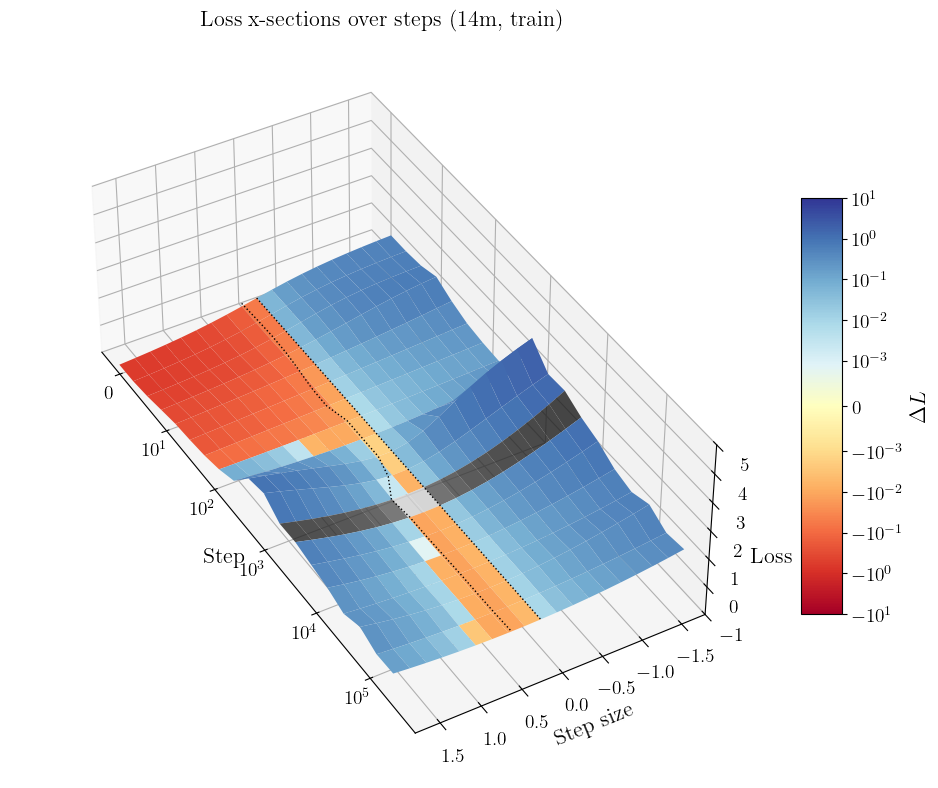

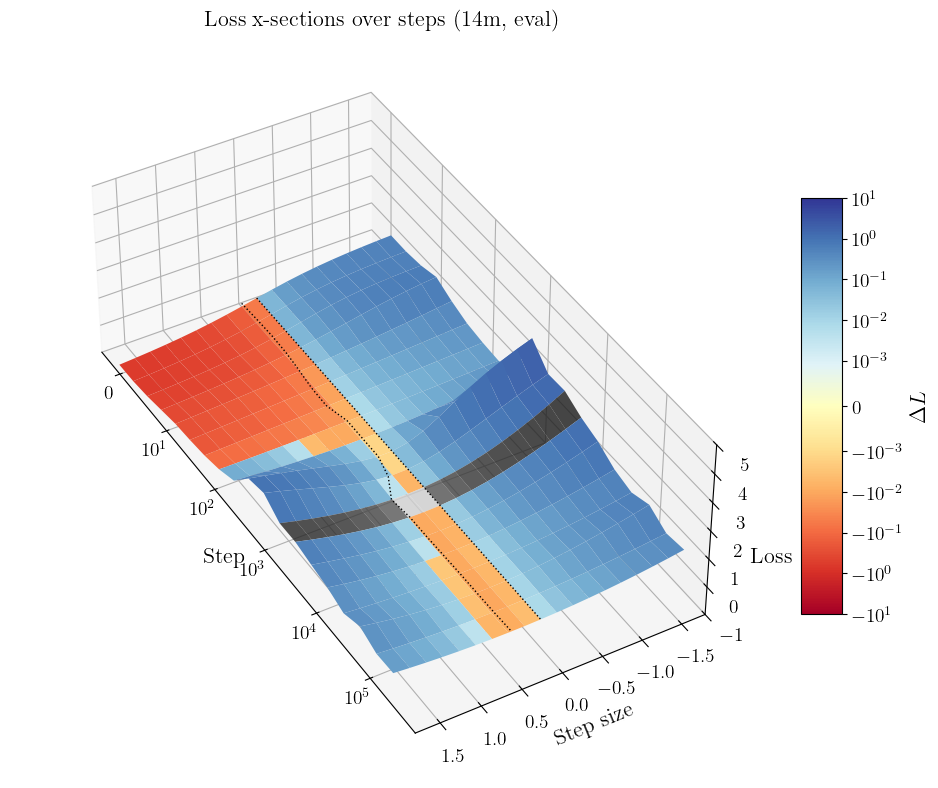

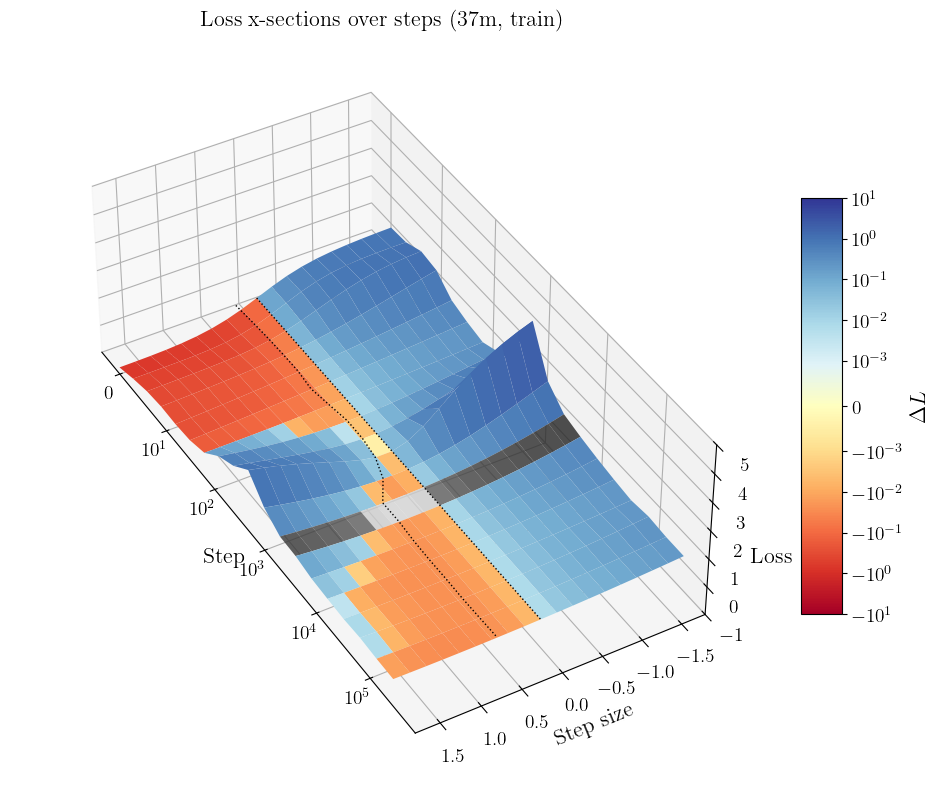

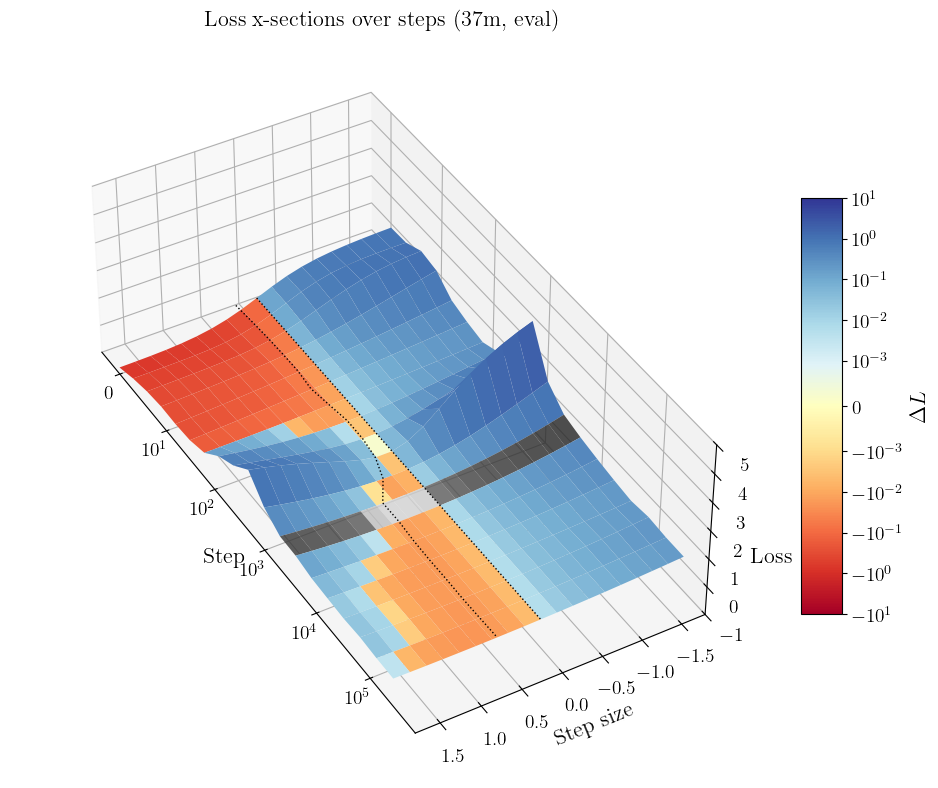

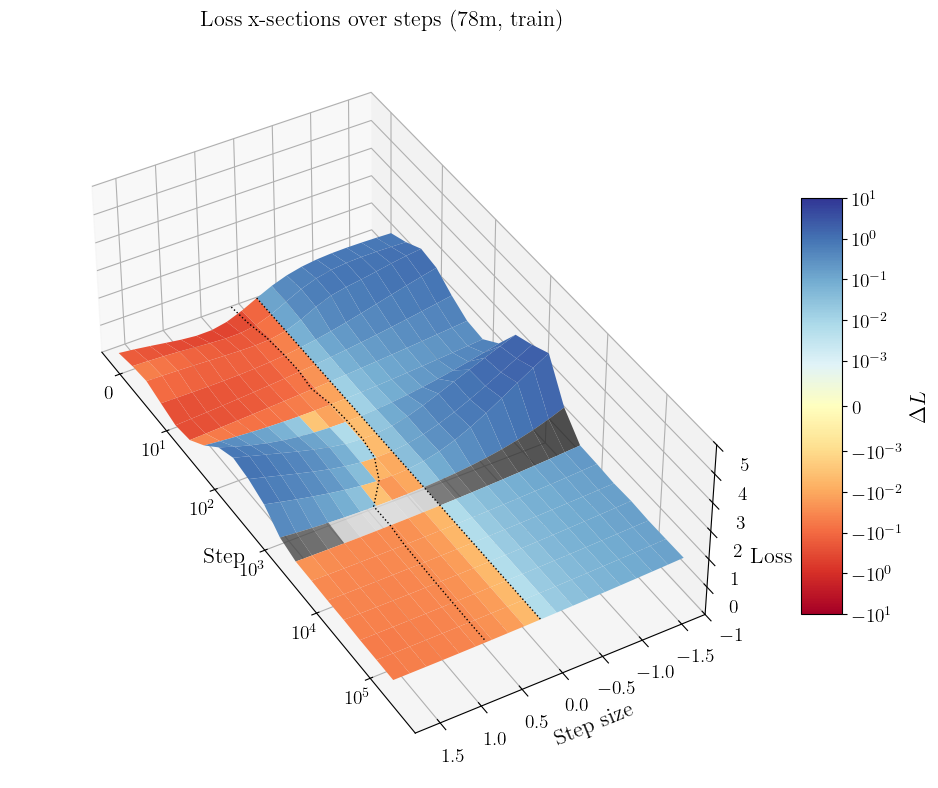

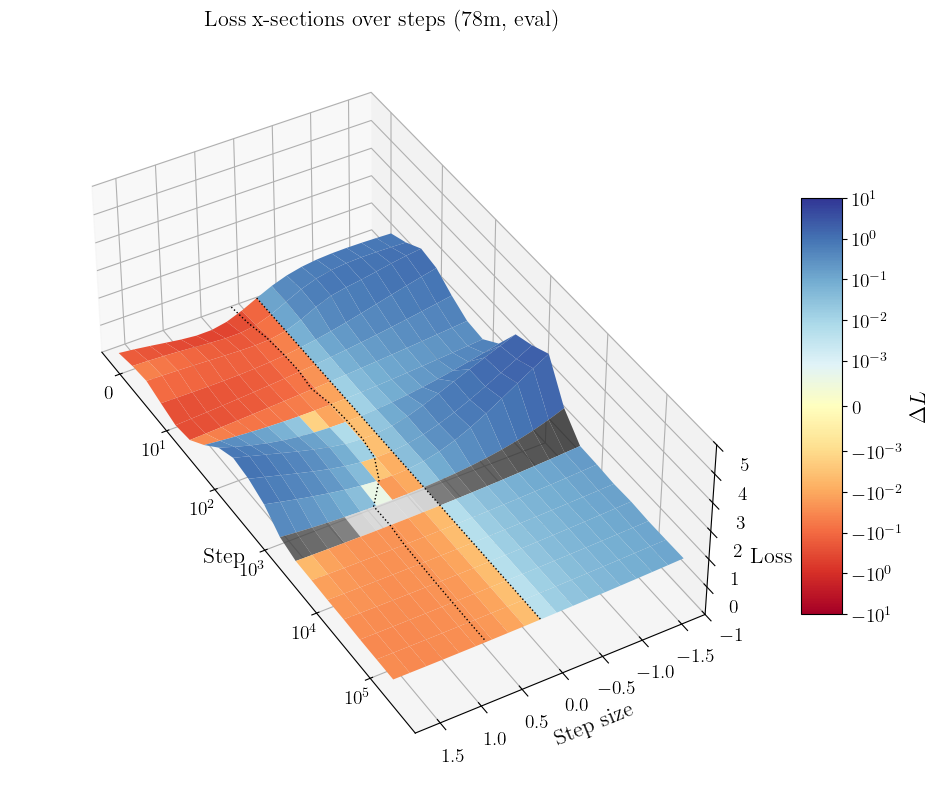

In [5]:
train_batch_step = 300_000
eval_batch_step = 300_001

cmap = get_cmap('RdYlBu')
linthresh = 1e-3
norm = SymLogNorm(linthresh=linthresh, vmin=-10, vmax=10, base=10)

for i,run in enumerate(runs_to_plot):
    for split in ['train', 'eval']:
        loss_xsections = []
        actual_stepsizes = []
        steps = get_olmo_model_steps(run)
        for step in steps:
            print(f"[run={run}][step={step}][split={split}]", end='\r')
            if split == 'train': metrics = get_metrics_train(run, step, train_batch_step)
            elif split == 'eval': metrics = get_metrics_eval(run, step, train_batch_step, eval_batch_step)
            else: raise Exception
            stepsizes = metrics['stepsizes']
            actual_stepsizes += [metrics['actual_stepsize']]
            loss_xsections += [torch.stack(metrics['losses']).mean(dim=(-1,-2))]

        # stack into array (n_steps, n_stepsizes)
        arr = torch.stack(loss_xsections)  # shape: (len(steps), len(stepsizes))
        zero_idx = stepsizes.index(0)
        arr = arr - arr[:,zero_idx].unsqueeze(1)

        # build coordinate grids
        x = torch.tensor(steps, dtype=torch.float32).log10()
        y = torch.tensor(stepsizes, dtype=torch.float32)
        Xg, Yg = torch.meshgrid(x, y)  # shapes: (len(steps), len(stepsizes))
        
        X = Xg.numpy()
        Y = Yg.numpy()
        Z = arr.numpy()

        # 3D surface plot
        fig = plt.figure(figsize=(12,18))
        ax3 = fig.add_subplot(111, projection='3d')
        ld1 = steps.index(2048)
        ld2 = steps.index(4096)

        surf = ax3.plot_surface(X[:ld1+1], Y[:ld1+1], Z[:ld1+1], cmap=cmap, norm=norm, edgecolor='none', rcount=100, ccount=100)
        ax3.plot_surface(X[ld2:], Y[ld2:], Z[ld2:], cmap=cmap, norm=norm, edgecolor='none', rcount=100, ccount=100)
        ax3.plot_surface(X[ld1:ld2+1], Y[ld1:ld2+1], Z[ld1:ld2+1], cmap='Greys', alpha=0.8,norm=norm, edgecolor='none', rcount=100, ccount=100)

        # zero-line
        x_zl = x
        y_zl = [0 for _ in x]
        z_zl = [0 for _ in x]
        ax3.plot(x_zl, y_zl, z_zl, color='black', linewidth=1, linestyle='dotted', zorder=10)
        ax3.plot(x_zl, actual_stepsizes, z_zl, color='black', linewidth=1, linestyle='dotted', zorder=10)
        

        ax3.set_xlabel('Step')
        ax3.set_ylabel('Step size')
        ax3.set_zlabel('Loss')

        xticks = [i for i in range(6)]
        xticklabels = [0] + [f"$10^{i}$" for i in range(1,6)]
        ax3.set_xticks(xticks, labels=xticklabels)

        ax3.set_ylim(y.max(), y.min())
        ax3.set_zlim(-1, 5)

        ax3.set_box_aspect((3.0, 1.5, 1.0))
        ax3.set_title(f'Loss x-sections over steps ({run.split("-")[-1]}, {split})')
        fig.colorbar(surf, ax=ax3, shrink=0.3, aspect=10, label='$\Delta L$')
        ax3.view_init(elev=40, azim=-30)
        plt.show()
        # break


## Loss landscape cross sections (ddp fix)

/tmp/ipykernel_2053452/1444561433.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdYlBu')


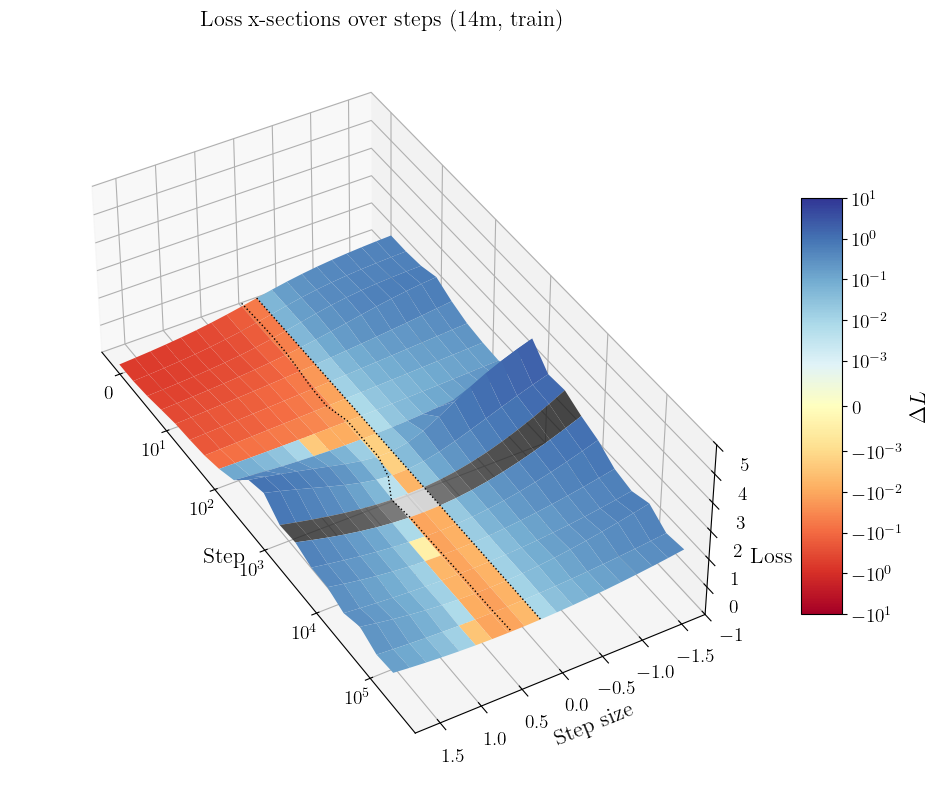

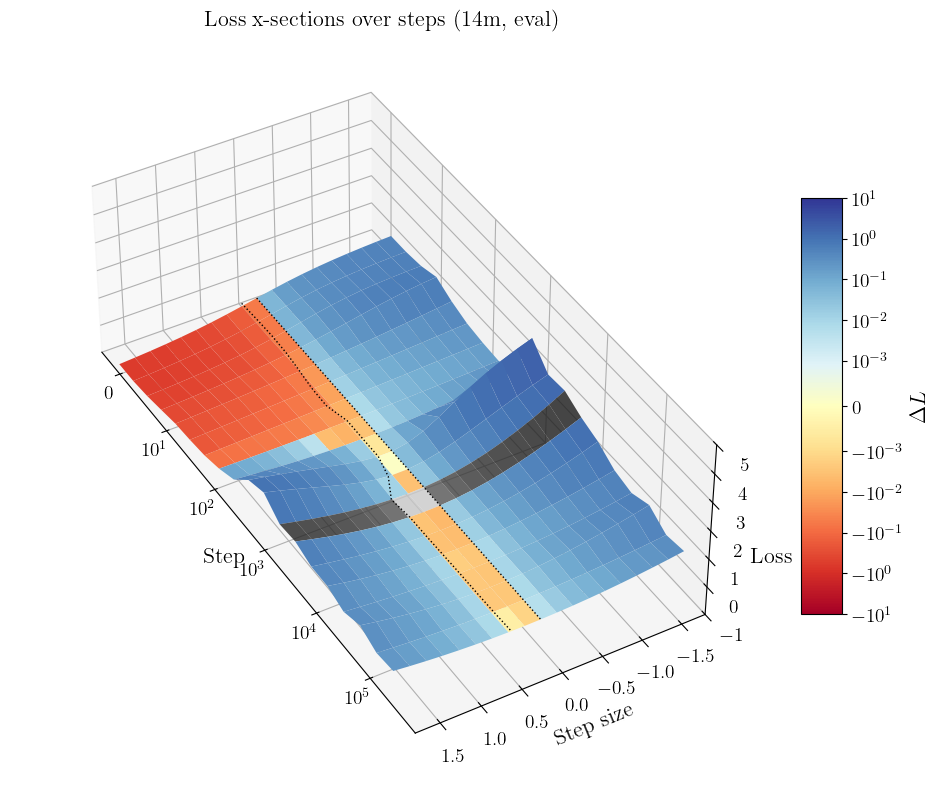

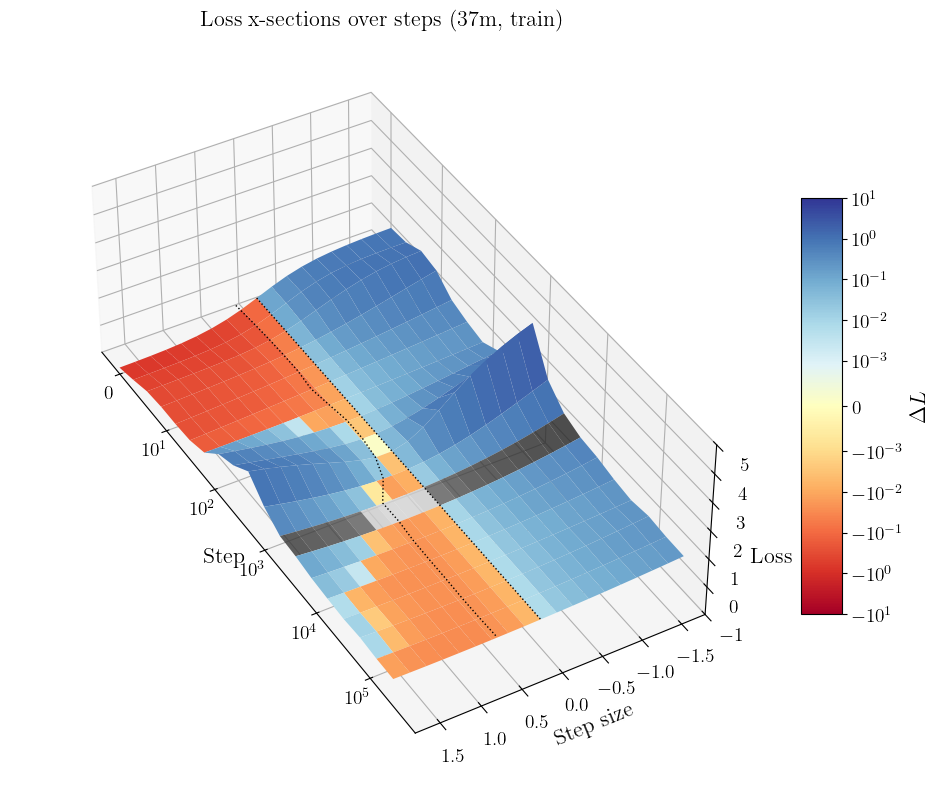

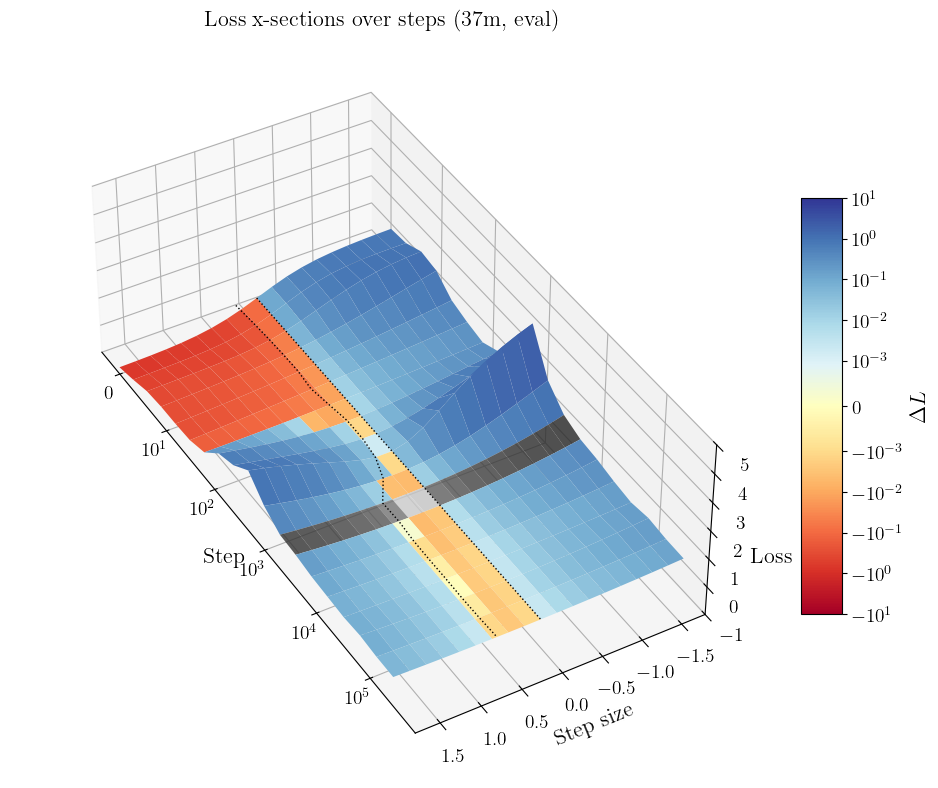

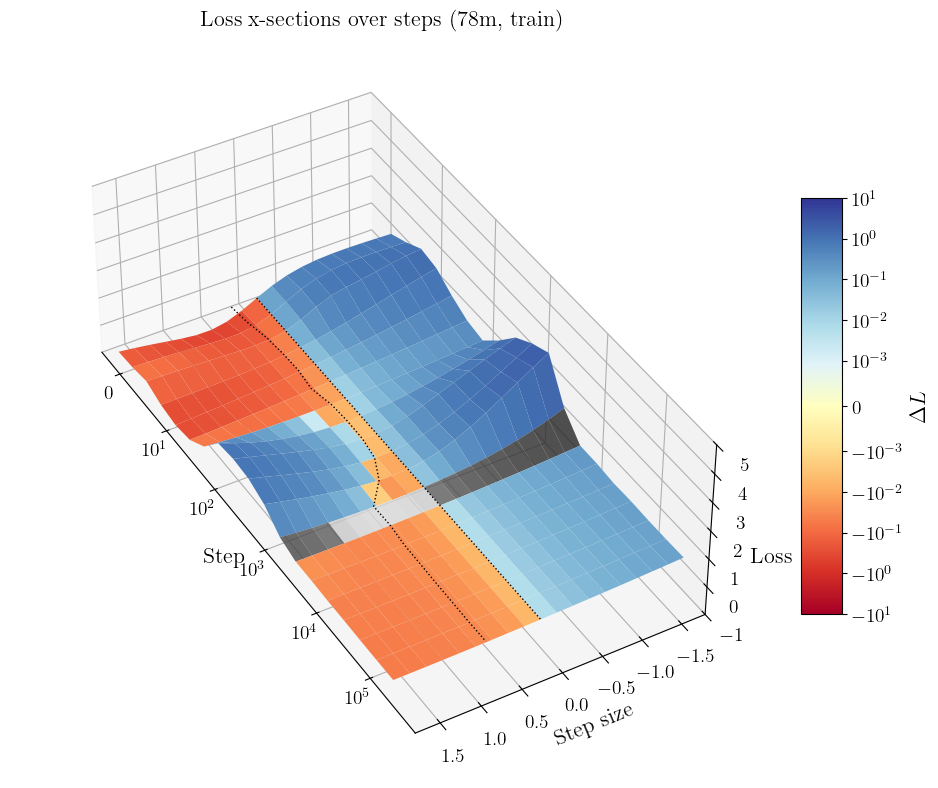

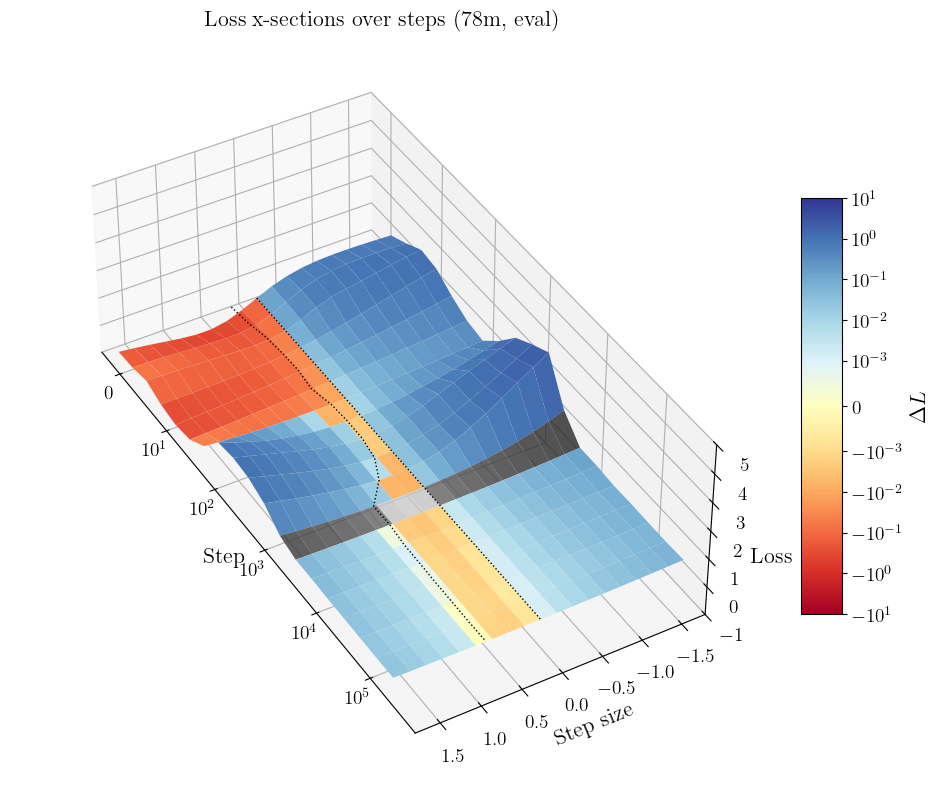

In [9]:
train_batch_step = 300_000
eval_batch_step = 300_001

cmap = get_cmap('RdYlBu')
linthresh = 1e-3
norm = SymLogNorm(linthresh=linthresh, vmin=-10, vmax=10, base=10)

for i,run in enumerate(runs_to_plot):
    for split in ['train', 'eval']:
        loss_xsections = []
        actual_stepsizes = []
        steps = get_olmo_model_steps(run)
        for step in steps:
            print(f"[run={run}][step={step}][split={split}]", end='\r')
            if split == 'train': metrics = get_metrics_train(run, step, train_batch_step, fix=True)
            elif split == 'eval': metrics = get_metrics_eval(run, step, train_batch_step, eval_batch_step, fix=True)
            else: raise Exception
            stepsizes = metrics['stepsizes']
            actual_stepsizes += [metrics['actual_stepsize']]
            loss_xsections += [torch.stack(metrics['losses']).mean(dim=(-1,-2))]

        # stack into array (n_steps, n_stepsizes)
        arr = torch.stack(loss_xsections)  # shape: (len(steps), len(stepsizes))
        zero_idx = stepsizes.index(0)
        arr = arr - arr[:,zero_idx].unsqueeze(1)

        # build coordinate grids
        x = torch.tensor(steps, dtype=torch.float32).log10()
        y = torch.tensor(stepsizes, dtype=torch.float32)
        Xg, Yg = torch.meshgrid(x, y)  # shapes: (len(steps), len(stepsizes))
        
        X = Xg.numpy()
        Y = Yg.numpy()
        Z = arr.numpy()

        # 3D surface plot
        fig = plt.figure(figsize=(12,18))
        ax3 = fig.add_subplot(111, projection='3d')
        ld1 = steps.index(2048)
        ld2 = steps.index(4096)

        surf = ax3.plot_surface(X[:ld1+1], Y[:ld1+1], Z[:ld1+1], cmap=cmap, norm=norm, edgecolor='none', rcount=100, ccount=100)
        ax3.plot_surface(X[ld2:], Y[ld2:], Z[ld2:], cmap=cmap, norm=norm, edgecolor='none', rcount=100, ccount=100)
        ax3.plot_surface(X[ld1:ld2+1], Y[ld1:ld2+1], Z[ld1:ld2+1], cmap='Greys', alpha=0.8,norm=norm, edgecolor='none', rcount=100, ccount=100)

        # zero-line
        x_zl = x
        y_zl = [0 for _ in x]
        z_zl = [0 for _ in x]
        ax3.plot(x_zl, y_zl, z_zl, color='black', linewidth=1, linestyle='dotted', zorder=10)
        ax3.plot(x_zl, actual_stepsizes, z_zl, color='black', linewidth=1, linestyle='dotted', zorder=10)
        

        ax3.set_xlabel('Step')
        ax3.set_ylabel('Step size')
        ax3.set_zlabel('Loss')

        xticks = [i for i in range(6)]
        xticklabels = [0] + [f"$10^{i}$" for i in range(1,6)]
        ax3.set_xticks(xticks, labels=xticklabels)

        ax3.set_ylim(y.max(), y.min())
        ax3.set_zlim(-1, 5)

        ax3.set_box_aspect((3.0, 1.5, 1.0))
        ax3.set_title(f'Loss x-sections over steps ({run.split("-")[-1]}, {split})')
        fig.colorbar(surf, ax=ax3, shrink=0.3, aspect=10, label='$\Delta L$')
        ax3.view_init(elev=40, azim=-30)
        plt.show()
        # break
